# Halo Occupation Distribution as a function of $\tau_0$

The HOD ⟨$N_\mathrm{gal}\,|\,M_h$⟩ is the most direct test of where dynamical friction matters in the high-$M_h$ regime. Two limits:

* $\tau_0 = 0$ (instant merging): every infalling satellite is destroyed, so $\langle N_\mathrm{sat}\,|\,M_h\rangle$ is suppressed. $\langle N_\mathrm{cen}\rangle$ stays at 1 by construction in occupied halos.
* $\tau_0 \to \infty$ (no merging): every galaxy that ever entered a halo is still there, so $\langle N_\mathrm{sat}\,|\,M_h\rangle$ is enhanced — particularly at large $M_h$ where merger histories are rich.

The signature in $\langle N_\mathrm{sat}\rangle(M_h)$ should grow with $M_h$ because the satellite population scales (very roughly) as $M_h$. So the *fractional* effect of $\tau_0$ on $\langle N_\mathrm{sat}\rangle$ is the cleanest probe — and it should remain large at $\log_{10}M_h \sim 14$.

## Method

* **Two-histogram HOD.** Numerator: galaxy counts (above a stellar-mass cut) binned by their host-halo mass $M_\mathrm{hhalo}$. Denominator: FOF group counts from `Trees/mphalo` (so empty halos contribute zero correctly).
* **FOF-central definition.** A galaxy is the central of its FOF group if `is_central == 1` and `mhalo / mhhalo > 0.5`. Satellites = total − FOF centrals.
* **Stellar-mass selection.** Default is $M_\star \geq 10^9\,M_\odot/h$; the second figure shows how the result depends on the cut.

All masses in $M_\odot/h$.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from utils.matplotlib_config import setconfig

sys.path.insert(0, str(Path.cwd()))
from tau0_helpers import (
    DEFAULT_IVOLS,
    RUNS,
    RUN_LABELS,
    SNAPSHOTS,
    collect_per_ivol,
    hod_per_ivol,
    safe_ratio,
    stack_per_ivol,
    style_for,
)

setconfig({
    'figure': {'figsize': (8, 6)},
    'font': {'size': 14},
    'legend': {'fontsize': 12, 'title_fontsize': 13},
    'axes': {'labelsize': 14},
})

halo_bins = np.arange(11.0, 15.51, 0.20)
halo_centers = 0.5 * (halo_bins[1:] + halo_bins[:-1])
ivols = DEFAULT_IVOLS

DEFAULT_MSTAR_CUT = 1e9  # Msun/h

## Compute per-ivol HOD for every (run, snapshot) at the default $M_\star$ cut

In [2]:
def make_summariser(mstar_min):
    return lambda d: hod_per_ivol(d, halo_bins, mstar_min=mstar_min)

stacked = {}
for snapshot in SNAPSHOTS:
    stacked[snapshot] = {}
    for run_label, run_path in RUNS.items():
        summaries = collect_per_ivol(run_path, snapshot, ivols, make_summariser(DEFAULT_MSTAR_CUT))
        stacked[snapshot][run_label] = stack_per_ivol(
            summaries,
            keys=('n_total', 'n_cen', 'n_sat', 'halo_counts'),
            nboot=500,
            seed=37,
        )
        n = stacked[snapshot][run_label]['n_used']
        print(f"{snapshot} {run_label:>10s}: {n:2d} ivols used")

iz271    Default: 16 ivols used
iz271     tau0=0: 16 ivols used
iz271   tau0=inf: 16 ivols used
iz207    Default: 16 ivols used
iz207     tau0=0: 16 ivols used
iz207   tau0=inf: 16 ivols used


## Figure 1 — Mean occupation $\langle N\,|\,M_h\rangle$

Three columns: total / centrals / satellites. Two rows for the two snapshots. Bands are bootstrap 16-84. Bins below the dashed grey line have fewer than 5 halos in the per-ivol sample (suppress those because the noise dominates).

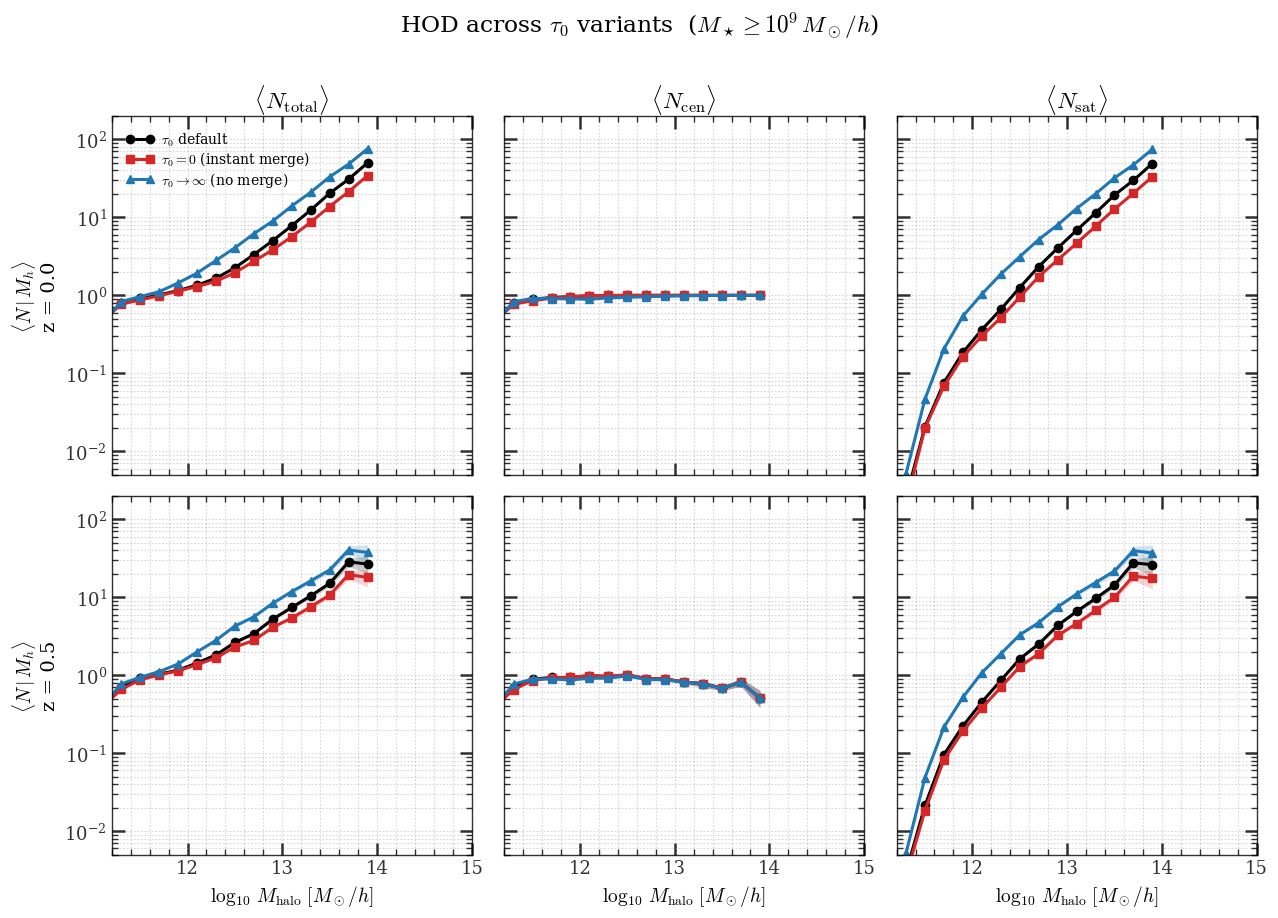

In [3]:
components = [
    ('n_total', r'$\langle N_\mathrm{total}\rangle$'),
    ('n_cen', r'$\langle N_\mathrm{cen}\rangle$'),
    ('n_sat', r'$\langle N_\mathrm{sat}\rangle$'),
]

min_halos = 3.0  # per-ivol mean halo count required to plot a bin

fig, axes = plt.subplots(
    len(SNAPSHOTS), len(components),
    figsize=(13, 4.6 * len(SNAPSHOTS)),
    sharex=True, sharey=True,
)
if len(SNAPSHOTS) == 1:
    axes = axes[None, :]

for i, snapshot in enumerate(SNAPSHOTS):
    z_val = SNAPSHOTS[snapshot][1]
    for j, (key, comp_label) in enumerate(components):
        ax = axes[i, j]
        for run_label in RUNS:
            s = stacked[snapshot][run_label]
            if s['n_used'] == 0 or key not in s:
                continue
            n_mean = s[key]['mean']
            lo = s[key]['boot_lo']
            hi = s[key]['boot_hi']
            n_halos = s['halo_counts']['mean']
            ok = np.isfinite(n_mean) & (n_halos >= min_halos)
            st = style_for(run_label)
            ax.plot(halo_centers[ok], np.maximum(n_mean[ok], 1e-3), '-', lw=2.2, **st)
            band_ok = ok & (lo > 0) & (hi > 0)
            ax.fill_between(
                halo_centers[band_ok], lo[band_ok], hi[band_ok],
                color=st['color'], alpha=0.20, linewidth=0,
            )
        ax.set_yscale('log')
        ax.set_ylim(5e-3, 200.0)
        ax.set_xlim(11.2, 15.0)
        ax.grid(True, alpha=0.3, which='both')
        if i == 0:
            ax.set_title(comp_label)
        if i == len(SNAPSHOTS) - 1:
            ax.set_xlabel(r'$\log_{10}\,M_\mathrm{halo}\ [M_\odot/h]$')
        if j == 0:
            ax.set_ylabel(r'$\langle N\,|\,M_h\rangle$' + f'\nz = {z_val:.1f}')
        if i == 0 and j == 0:
            ax.legend(loc='upper left', fontsize=10)
fig.suptitle(r'HOD across $\tau_0$ variants  ($M_\star \geq 10^9\,M_\odot/h$)', y=1.0)
plt.tight_layout()
plt.show()

## Figure 2 — Ratios relative to Default

The fractional shift in $\langle N_\mathrm{sat}\rangle$ is the headline diagnostic for $\tau_0$. We expect:

* $\tau_0=0$: ratio $\lesssim 1$, growing weaker (closer to 1) at large $M_h$ as the merger time becomes negligible regardless of $\tau_0$.
* $\tau_0=\infty$: ratio $> 1$, growing with $M_h$ as more never-merged satellites accumulate.

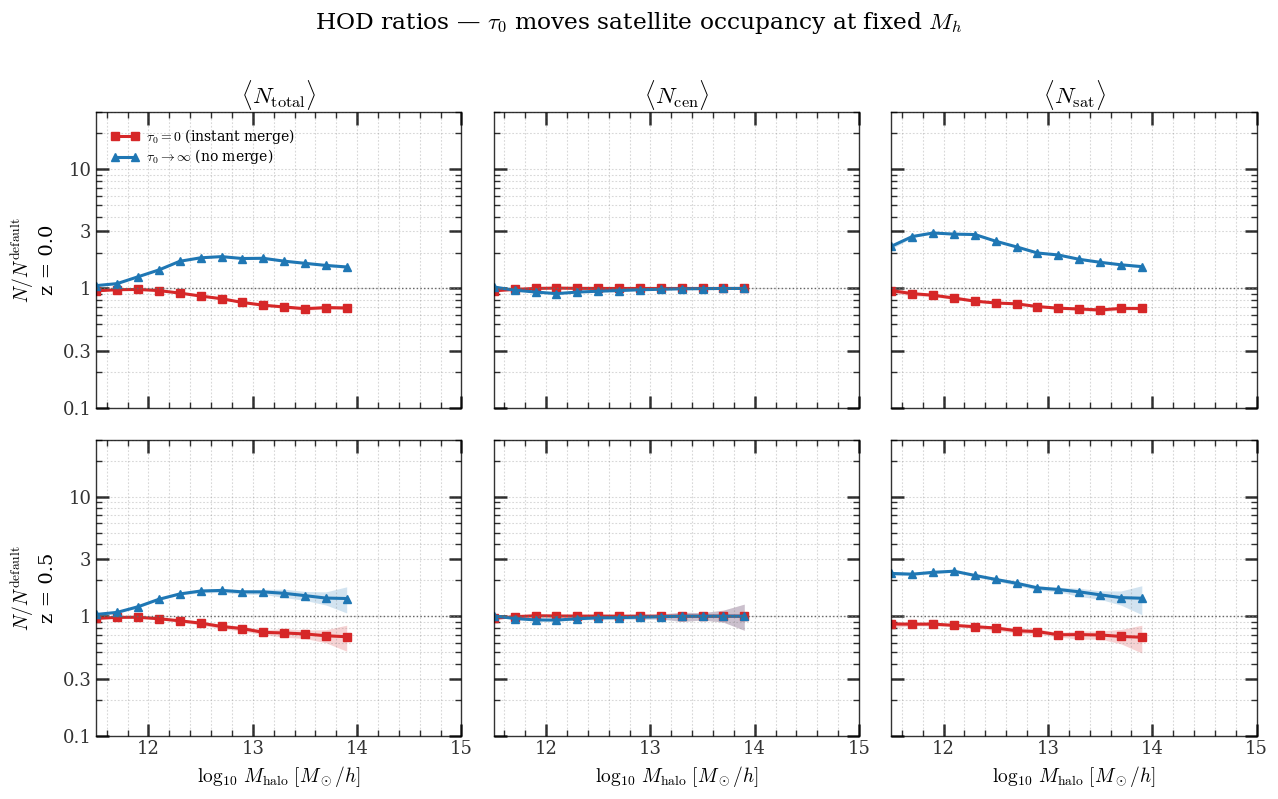

In [4]:
fig, axes = plt.subplots(
    len(SNAPSHOTS), len(components),
    figsize=(13, 4.0 * len(SNAPSHOTS)),
    sharex=True, sharey=True,
)
if len(SNAPSHOTS) == 1:
    axes = axes[None, :]

for i, snapshot in enumerate(SNAPSHOTS):
    z_val = SNAPSHOTS[snapshot][1]
    for j, (key, comp_label) in enumerate(components):
        ax = axes[i, j]
        s_def = stacked[snapshot]['Default']
        if s_def['n_used'] == 0:
            continue
        n_def = s_def[key]['mean']
        n_halos = s_def['halo_counts']['mean']
        for run_label in RUNS:
            if run_label == 'Default':
                continue
            s = stacked[snapshot][run_label]
            ratio = safe_ratio(s[key]['mean'], n_def)
            ratio_lo = safe_ratio(s[key]['boot_lo'], n_def)
            ratio_hi = safe_ratio(s[key]['boot_hi'], n_def)
            ok = np.isfinite(ratio) & (n_halos >= min_halos) & (n_def > 1e-3)
            st = style_for(run_label)
            ax.plot(halo_centers[ok], ratio[ok], '-', lw=2.2, **st)
            ax.fill_between(
                halo_centers[ok], ratio_lo[ok], ratio_hi[ok],
                color=st['color'], alpha=0.20, linewidth=0,
            )
        ax.axhline(1.0, color='0.4', ls=':', lw=1)
        ax.set_yscale('log')
        ax.set_ylim(0.1, 30.0)
        ax.set_yticks([0.1, 0.3, 1.0, 3.0, 10.0])
        ax.set_yticklabels(['0.1', '0.3', '1', '3', '10'])
        ax.set_xlim(11.5, 15.0)
        ax.grid(True, alpha=0.3, which='both')
        if i == 0:
            ax.set_title(comp_label)
        if i == len(SNAPSHOTS) - 1:
            ax.set_xlabel(r'$\log_{10}\,M_\mathrm{halo}\ [M_\odot/h]$')
        if j == 0:
            ax.set_ylabel(r'$N/N^\mathrm{default}$' + f'\nz = {z_val:.1f}')
        if i == 0 and j == 0:
            ax.legend(loc='upper left', fontsize=10)
fig.suptitle(r'HOD ratios — $\tau_0$ moves satellite occupancy at fixed $M_h$', y=1.0)
plt.tight_layout()
plt.show()

## Figure 3 — Power-law fit to $\langle N_\mathrm{sat}\rangle(M_h)$ at large $M_h$

In the cluster regime $\langle N_\mathrm{sat}\rangle \propto M_h^\alpha$ with $\alpha \sim 1$. $\tau_0$ should change the *normalisation* and possibly the slope $\alpha$. We fit $\log_{10}\langle N_\mathrm{sat}\rangle = \alpha\,\log_{10}M_h + \beta$ on bins between $\log_{10}M_h = 12.5$ and the highest reliably-populated bin.

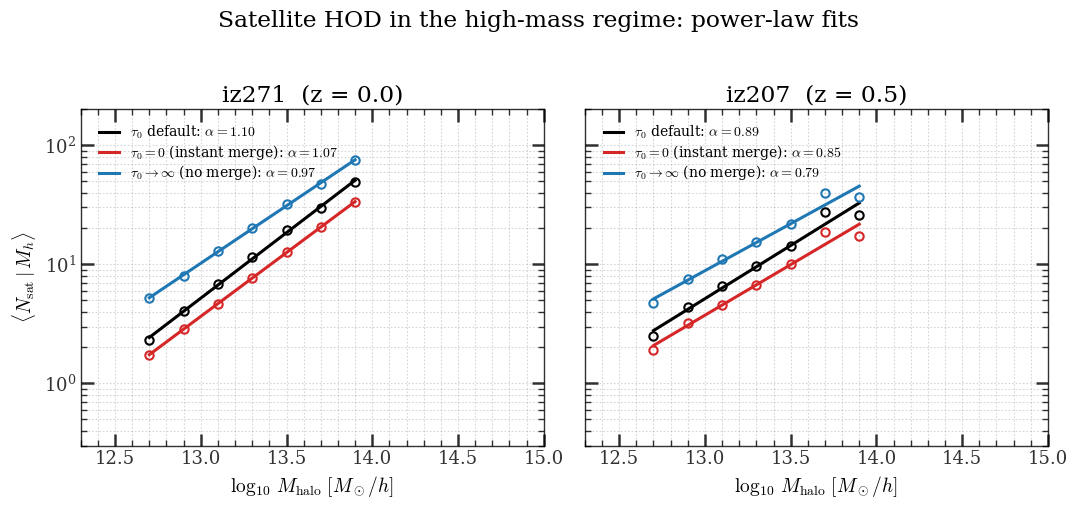

,snapshot,z,run,alpha,log10_normalization_at_logMh_13,n_bins_used
0,iz271,0.0,Default,1.100,0.715,7
1,iz271,0.0,tau0=0,1.071,0.562,7
2,iz271,0.0,tau0=inf,0.966,1.008,7
3,iz207,0.5,Default,0.893,0.711,7
4,iz207,0.5,tau0=0,0.849,0.572,7
5,iz207,0.5,tau0=inf,0.789,0.946,7


In [5]:
import pandas as pd

fit_lo, fit_hi = 12.5, 15.0
min_n_for_fit = 0.5

fit_rows = []
fig, axes = plt.subplots(1, len(SNAPSHOTS), figsize=(11, 5.0), sharey=True)
if len(SNAPSHOTS) == 1:
    axes = [axes]

for j, snapshot in enumerate(SNAPSHOTS):
    z_val = SNAPSHOTS[snapshot][1]
    ax = axes[j]
    for run_label in RUNS:
        s = stacked[snapshot][run_label]
        if s['n_used'] == 0:
            continue
        n_sat = s['n_sat']['mean']
        n_halos = s['halo_counts']['mean']
        st = style_for(run_label)
        ok = np.isfinite(n_sat) & (n_sat > min_n_for_fit) & (halo_centers >= fit_lo) & (halo_centers <= fit_hi) & (n_halos >= min_halos)
        ax.plot(halo_centers[ok], n_sat[ok], 'o', ms=6, mec=st['color'], mfc='none', mew=1.5)
        if ok.sum() >= 3:
            x = halo_centers[ok]
            y = np.log10(n_sat[ok])
            alpha, beta = np.polyfit(x, y, 1)
            x_fine = np.linspace(x.min(), x.max(), 50)
            ax.plot(x_fine, 10 ** (alpha * x_fine + beta), '-', lw=2.2,
                    color=st['color'],
                    label=f"{st['label']}: $\\alpha = {alpha:.2f}$")
            fit_rows.append({
                'snapshot': snapshot, 'z': z_val, 'run': run_label,
                'alpha': round(alpha, 3), 'log10_normalization_at_logMh_13': round(alpha * 13.0 + beta, 3),
                'n_bins_used': int(ok.sum()),
            })
    ax.set_yscale('log')
    ax.set_xlim(12.3, 15.0)
    ax.set_ylim(0.3, 200.0)
    ax.set_xlabel(r'$\log_{10}\,M_\mathrm{halo}\ [M_\odot/h]$')
    ax.set_title(f'{snapshot}  (z = {z_val:.1f})')
    ax.grid(True, alpha=0.3, which='both')
    if j == 0:
        ax.set_ylabel(r'$\langle N_\mathrm{sat}\,|\,M_h\rangle$')
    ax.legend(loc='upper left', fontsize=10)
fig.suptitle(r'Satellite HOD in the high-mass regime: power-law fits', y=1.02)
plt.tight_layout()
plt.show()

fit_df = pd.DataFrame(fit_rows)
fit_df

## Figure 4 — Stellar-mass-cut sensitivity

Whether the τ₀ effect grows or shrinks with the threshold tells you which satellite populations dynamical friction operates on. We sweep the cut from $10^9$ to $10^{11}\,M_\odot/h$ at $z=0$.

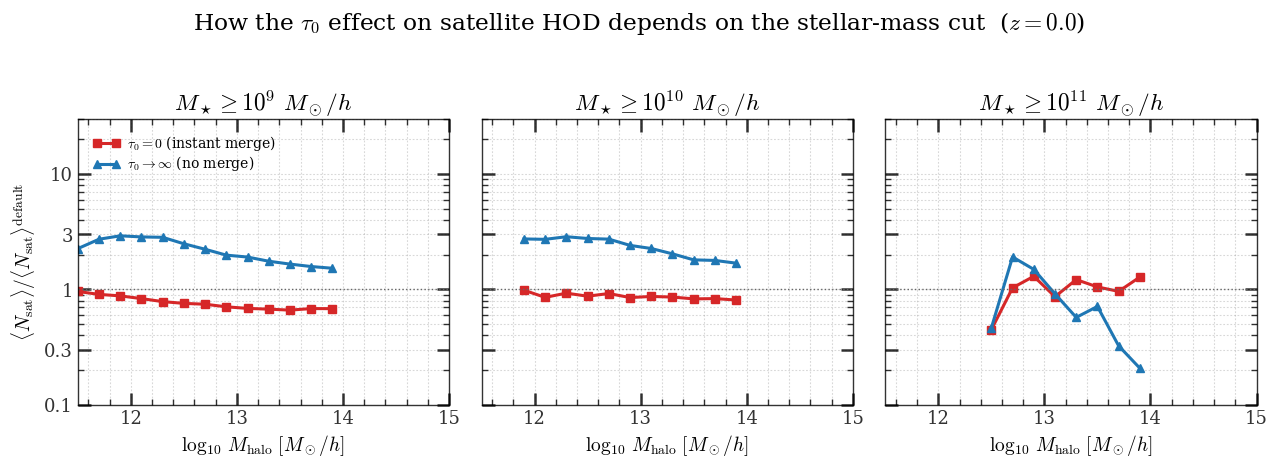

In [6]:
snapshot = 'iz271'
z_val = SNAPSHOTS[snapshot][1]
mstar_cuts = [1e9, 1e10, 1e11]

fig, axes = plt.subplots(1, len(mstar_cuts), figsize=(13, 4.6), sharex=True, sharey=True)
for j, mstar_cut in enumerate(mstar_cuts):
    ax = axes[j]
    s_def = None
    cuts_results = {}
    for run_label, run_path in RUNS.items():
        summaries = collect_per_ivol(
            run_path, snapshot, ivols, make_summariser(mstar_cut)
        )
        s = stack_per_ivol(
            summaries,
            keys=('n_sat', 'halo_counts'),
            nboot=300,
            seed=41,
        )
        cuts_results[run_label] = s
    s_def = cuts_results['Default']
    n_def = s_def['n_sat']['mean']
    n_halos = s_def['halo_counts']['mean']
    for run_label in RUNS:
        if run_label == 'Default':
            continue
        s = cuts_results[run_label]
        ratio = safe_ratio(s['n_sat']['mean'], n_def)
        ok = np.isfinite(ratio) & (n_halos >= min_halos) & (n_def > 1e-3)
        st = style_for(run_label)
        ax.plot(halo_centers[ok], ratio[ok], '-', lw=2.2, **st)
    ax.axhline(1.0, color='0.4', ls=':', lw=1)
    ax.set_yscale('log')
    ax.set_ylim(0.1, 30.0)
    ax.set_xlim(11.5, 15.0)
    ax.set_yticks([0.1, 0.3, 1.0, 3.0, 10.0])
    ax.set_yticklabels(['0.1', '0.3', '1', '3', '10'])
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlabel(r'$\log_{10}\,M_\mathrm{halo}\ [M_\odot/h]$')
    ax.set_title(rf'$M_\star \geq 10^{{{int(np.log10(mstar_cut))}}}$ $M_\odot/h$')
    if j == 0:
        ax.set_ylabel(r'$\langle N_\mathrm{sat}\rangle/\langle N_\mathrm{sat}\rangle^\mathrm{default}$')
        ax.legend(loc='upper left', fontsize=10)
fig.suptitle(
    f'How the $\\tau_0$ effect on satellite HOD depends on the stellar-mass cut  ($z={z_val:.1f}$)',
    y=1.02,
)
plt.tight_layout()
plt.show()

## Quantitative summary

Halo masses where the τ₀ effect on $\langle N_\mathrm{sat}\rangle$ peaks, and the size of the bracket at three diagnostic masses.

In [7]:
rows = []
for snapshot in SNAPSHOTS:
    z_val = SNAPSHOTS[snapshot][1]
    s_def = stacked[snapshot]['Default']
    if s_def['n_used'] == 0:
        continue
    for log_mh_target in (12.0, 13.0, 14.0):
        i = int(np.argmin(np.abs(halo_centers - log_mh_target)))
        n_def_sat = s_def['n_sat']['mean'][i]
        n_halos = s_def['halo_counts']['mean'][i]
        for run_label in RUNS:
            s = stacked[snapshot][run_label]
            if s['n_used'] == 0:
                continue
            row = {
                'snapshot': snapshot,
                'z': z_val,
                'log10_Mhalo': log_mh_target,
                'run': run_label,
                'N_total': round(s['n_total']['mean'][i], 3),
                'N_cen': round(s['n_cen']['mean'][i], 3),
                'N_sat': round(s['n_sat']['mean'][i], 3),
                'N_sat/default': round(safe_ratio(np.array([s['n_sat']['mean'][i]]), np.array([n_def_sat]))[0], 3) if n_def_sat > 0 else np.nan,
                'n_halos_per_ivol': int(n_halos),
            }
            rows.append(row)
df = pd.DataFrame(rows)
df

,snapshot,z,log10_Mhalo,run,N_total,N_cen,N_sat,N_sat/default,n_halos_per_ivol
0,iz271,0.0,12.0,Default,1.347,0.984,0.363,1.000,232
1,iz271,0.0,12.0,tau0=0,1.293,0.991,0.302,0.832,232
2,iz271,0.0,12.0,tau0=inf,1.926,0.891,1.035,2.852,232
3,iz271,0.0,13.0,Default,7.808,1.000,6.808,1.000,32
4,iz271,0.0,13.0,tau0=0,5.654,1.000,4.654,0.684,32
5,iz271,0.0,13.0,tau0=inf,13.970,0.984,12.986,1.908,32
6,iz271,0.0,14.0,Default,75.145,0.938,74.207,1.000,2
7,iz271,0.0,14.0,tau0=0,50.258,0.938,49.321,0.665,2
8,iz271,0.0,14.0,tau0=inf,108.232,0.938,107.295,1.446,2
9,iz207,0.5,12.0,Default,1.434,0.982,0.452,1.000,232


## Interpretation

* **$\langle N_\mathrm{cen}\rangle$ saturates at 1** in halos massive enough to host a galaxy above the threshold, irrespective of $\tau_0$. The small gap between runs at intermediate $M_h$ is a *side-effect* of the central-mass shift: when $\tau_0=\infty$, the central is starved and may fail the $M_\star$ cut.
* **$\langle N_\mathrm{sat}\rangle$ is the headline diagnostic.** The $\tau_0=\infty$ run inflates the satellite occupancy at every halo mass (Fig 2 right column); the asymmetry between Default and $\tau_0=0$ tells you how close the Default already is to the instant-merging limit.
* **Power-law slope $\alpha$ (Fig 3)** can shift between runs if dynamical friction is more important for low-mass satellites (which take longer to spiral in than they would in the $\tau_0=0$ limit).
* **$M_\star$-cut sensitivity (Fig 4)** distinguishes whether the $\tau_0$ effect is dominated by low-mass or high-mass satellites. If the gap shrinks with rising cut, the $\tau_0$ knob is acting mostly on small satellites; if it grows, it's the massive ones that fail to merge.